In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # Para gráficos más avanzados

# Cargar directamente el dataset ya limpio
path = '/content/drive/MyDrive/datos DEIS/mortalidad_validado.parquet'
df = pd.read_parquet(path)

#Verificación rápida de carga
print(f"Dataset cargado correctamente.")
print(f"Total de registros: {len(df)}")
print(f"Total de defunciones (CUENTA): {df['CUENTA'].sum():,}")


Dataset cargado correctamente.
Total de registros: 922900
Total de defunciones (CUENTA): 6,387,487


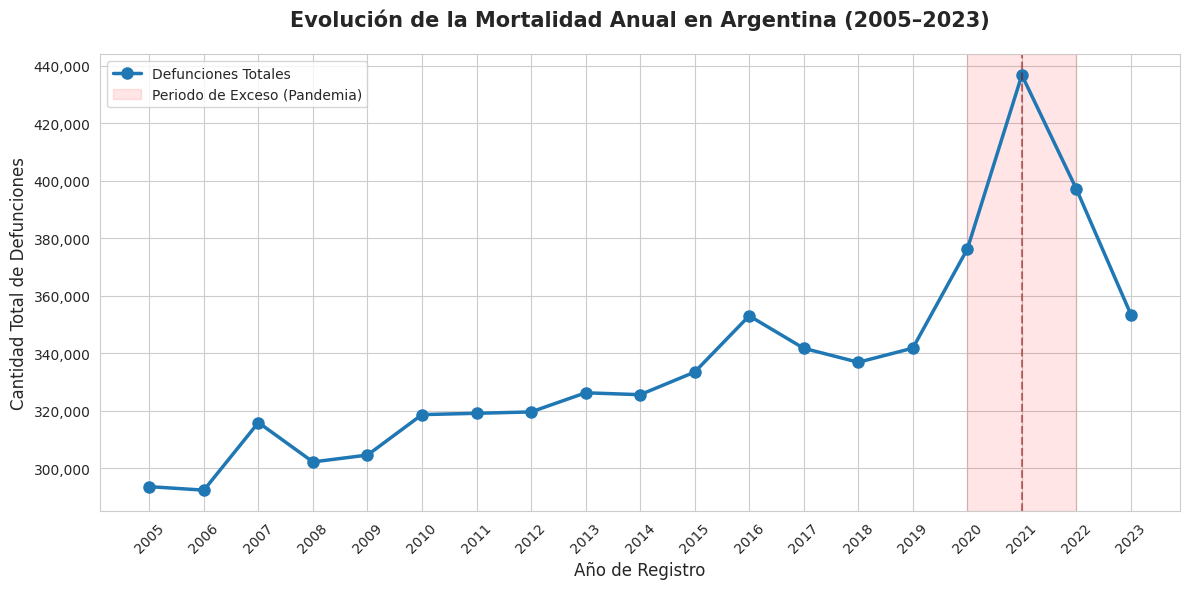

Análisis visual completado. Promedio histórico pre-pandemia (2005-2019): 321,595 muertes.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Agrupamiento de datos por año (Suma ponderada por CUENTA)
tendencia_anual = df.groupby('anio')['CUENTA'].sum().reset_index()

# 2. Configuración estética del gráfico
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# 3. Creación de la línea de tendencia
plt.plot(tendencia_anual['anio'], tendencia_anual['CUENTA'],
         marker='o', markersize=8, color='#1f77b4', linewidth=2.5, label='Defunciones Totales')

# 4. Enriquecimiento visual y anotaciones
plt.title('Evolución de la Mortalidad Anual en Argentina (2005–2023)', fontsize=15, pad=20, fontweight='bold')
plt.xlabel('Año de Registro', fontsize=12)
plt.ylabel('Cantidad Total de Defunciones', fontsize=12)
plt.xticks(tendencia_anual['anio'], rotation=45)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ','))) # Formato con miles

# Destacar el periodo de exceso de mortalidad (Pandemia)
plt.axvspan(2020, 2022, color='red', alpha=0.1, label='Periodo de Exceso (Pandemia)')
plt.axvline(x=2021, color='darkred', linestyle='--', alpha=0.5)

plt.legend(frameon=True, loc='upper left')
plt.tight_layout()

# Guardar y mostrar
plt.savefig('tendencia_mortalidad_argentina.png', dpi=300)
plt.show()

print(f"Análisis visual completado. Promedio histórico pre-pandemia (2005-2019): {tendencia_anual[tendencia_anual['anio'] < 2020]['CUENTA'].mean():,.0f} muertes.")

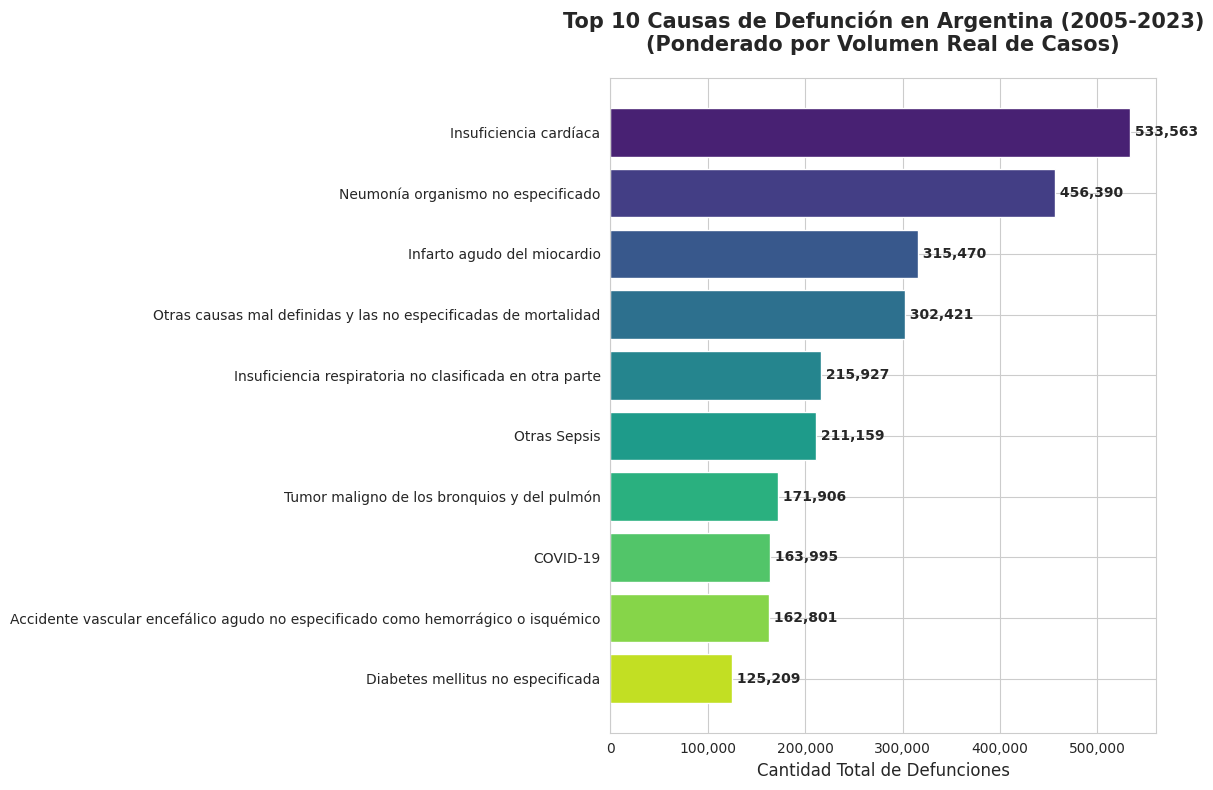

In [ ]:
# 1. Cálculo de Frecuencias Reales (Ponderado por CUENTA)
causas_stats = df.groupby(['CAUSA_norm', 'causa_desc'])['CUENTA'].sum().reset_index()
top_10 = causas_stats.nlargest(10, 'CUENTA')

# Calcular el porcentaje sobre el total general (6.387.487)
total_general = df['CUENTA'].sum()
top_10['Porcentaje (%)'] = (top_10['CUENTA'] / total_general * 100).round(2)



# --- GRÁFICO ---
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# Crear barras horizontales para mejor lectura de las descripciones
colors = sns.color_palette("viridis", 10)
bars = plt.barh(top_10['causa_desc'], top_10['CUENTA'], color=colors)

# Añadir etiquetas de datos al final de cada barra
for bar in bars:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2,
             f' {int(width):,}', va='center', fontsize=10, fontweight='bold')

plt.title('Top 10 Causas de Defunción en Argentina (2005-2023)\n(Ponderado por Volumen Real de Casos)',
          fontsize=15, pad=20, fontweight='bold')
plt.xlabel('Cantidad Total de Defunciones', fontsize=12)
plt.gca().invert_yaxis() # La más importante arriba
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.tight_layout()
plt.savefig('top_10_causas_mortalidad.png', dpi=300)
plt.show()

In [ ]:
print("--- DATOS PARA EL INFORME DE CAUSAS (TOP 10) ---")
print(top_10[['CAUSA_norm', 'causa_desc', 'CUENTA', 'Porcentaje (%)']].to_string(index=False))
print(f"\nSuma del Top 10: {top_10['CUENTA'].sum():,}")
print(f"Representatividad del Top 10 sobre el total: {top_10['Porcentaje (%)'].sum():.2f}%")

--- DATOS PARA EL INFORME DE CAUSAS (TOP 10) ---
CAUSA_norm                                                                       causa_desc  CUENTA  Porcentaje (%)
       I50                                                           Insuficiencia cardíaca  533563            8.35
       J18                                               Neumonía organismo no especificado  456390            7.15
       I21                                                      Infarto agudo del miocardio  315470            4.94
       R99                  Otras causas mal definidas y las no especificadas de mortalidad  302421            4.73
       J96                          Insuficiencia respiratoria no clasificada en otra parte  215927            3.38
       A41                                                                     Otras Sepsis  211159            3.31
       C34                                      Tumor maligno de los bronquios y del pulmón  171906            2.69
  COVID-19             

Análisis de la Mortalidad por Causas (2005-2023)

1. Concentración de la Carga de Mortalidad:El Top 10 de causas de muerte concentra un total de $2.658.841$ defunciones, lo que representa el $41,63\%$ del universo total de la serie ($6.387.487$ casos). Esto indica una alta concentración de la mortalidad en un grupo reducido de patologías, principalmente de tipo crónico y respiratorio.

2. Predominio Cardiovascular:La Insuficiencia cardíaca (I50) y el Infarto agudo del miocardio (I21) suman juntas $849.033$ muertes ($13,29\%$ del total nacional). La insuficiencia cardíaca se posiciona como la causa individual número uno, reflejando el impacto del envejecimiento poblacional y las enfermedades crónicas no transmisibles (ECNT).

3. El Desafío de las Infecciones Respiratorias y COVID-19:
+ La Neumonía (J18) es la segunda causa nacional con $456.390$ fallecimientos ($7,15\%$).
+ El COVID-19, a pesar de haber estado presente activamente solo en 4 de los 19 años de la serie, ya se ubica en el puesto 8 con $163.995$ muertes ($2,57\%$). Este dato es alarmante, pues su impacto acumulado en poco tiempo superó a causas históricas como la Diabetes o los Accidentes Cerebrovasculares (I64).

4. Alerta sobre la Calidad del Registro (R99):Un hallazgo crítico es la posición de las Causas mal definidas (R99) en el 4.º lugar, con $302.421$ casos ($4,73\%$). Casi 5 de cada 100 muertes en Argentina no cuentan con un diagnóstico preciso en el certificado de defunción. Para la DEIS, esto puede representar un área de mejora prioritaria   (en la capacitación de los profesionales médicos que firman los certificados.)

5. Enfermedades Crónicas y Metabólicas:El Tumor maligno de pulmón (C34) y la Diabetes mellitus (E14) cierran el ranking, sumando casi $300.000$ muertes adicionales, confirmando la transición epidemiológica hacia causas vinculadas a estilos de vida y factores de riesgo prolongados.

In [ ]:
import numpy as np

# Preparar los datos: Agrupar por Edad y Sexo (solo Varones=1 y Mujeres=2)
# Usamos EDAD_orden para que la pirámide respete el ciclo de vida
piramide_data = df[df['SEXO_norm'].isin(['1', '2'])].groupby(['EDAD_orden', 'EDAD_norm', 'SEXO_norm'])['CUENTA'].sum().reset_index()

# 2. Separar datos para la pirámide
hombres = piramide_data[piramide_data['SEXO_norm'] == '1'].copy()
mujeres = piramide_data[piramide_data['SEXO_norm'] == '2'].copy()

# Para la pirámide, los valores de hombres deben ser negativos para ir a la izquierda
hombres['CUENTA_PLOT'] = -hombres['CUENTA']

# --- PARTE 1: DEPURACIÓN PARA CONSOLA (DATOS DEL INFORME) ---
reporte_edad = piramide_data.pivot_table(index=['EDAD_orden', 'EDAD_norm'],
                                        columns='SEXO_norm',
                                        values='CUENTA',
                                        aggfunc='sum').reset_index()
reporte_edad.columns = ['Orden', 'Rango Etario', 'Varones', 'Mujeres']
reporte_edad['Total'] = reporte_edad['Varones'] + reporte_edad['Mujeres']
reporte_edad['Indice_Sobremortalidad_M'] = (reporte_edad['Varones'] / reporte_edad['Mujeres']).round(2)

print("--- DATOS PARA EL INFORME DE PIRÁMIDE ETARIA ---")
print(reporte_edad[['Rango Etario', 'Varones', 'Mujeres', 'Indice_Sobremortalidad_M']].to_string(index=False))



--- DATOS PARA EL INFORME DE PIRÁMIDE ETARIA ---
   Rango Etario  Varones  Mujeres  Indice_Sobremortalidad_M
 Menor de 1 año    77535    60228                      1.29
          1 a 9    20888    16839                      1.24
        10 a 14     9908     7190                      1.38
        15 a 19    33608    13979                      2.40
        20 a 24    47007    16183                      2.90
        25 a 29    45639    18816                      2.43
        30 a 34    46185    23637                      1.95
        35 a 39    52490    31527                      1.66
        40 a 44    67647    43227                      1.56
        45 a 49    94055    59732                      1.57
        50 a 54   140729    83708                      1.68
        55 a 59   205274   118832                      1.73
        60 a 64   281734   166045                      1.70
        65 a 69   357213   217695                      1.64
        70 a 74   410002   282740                  

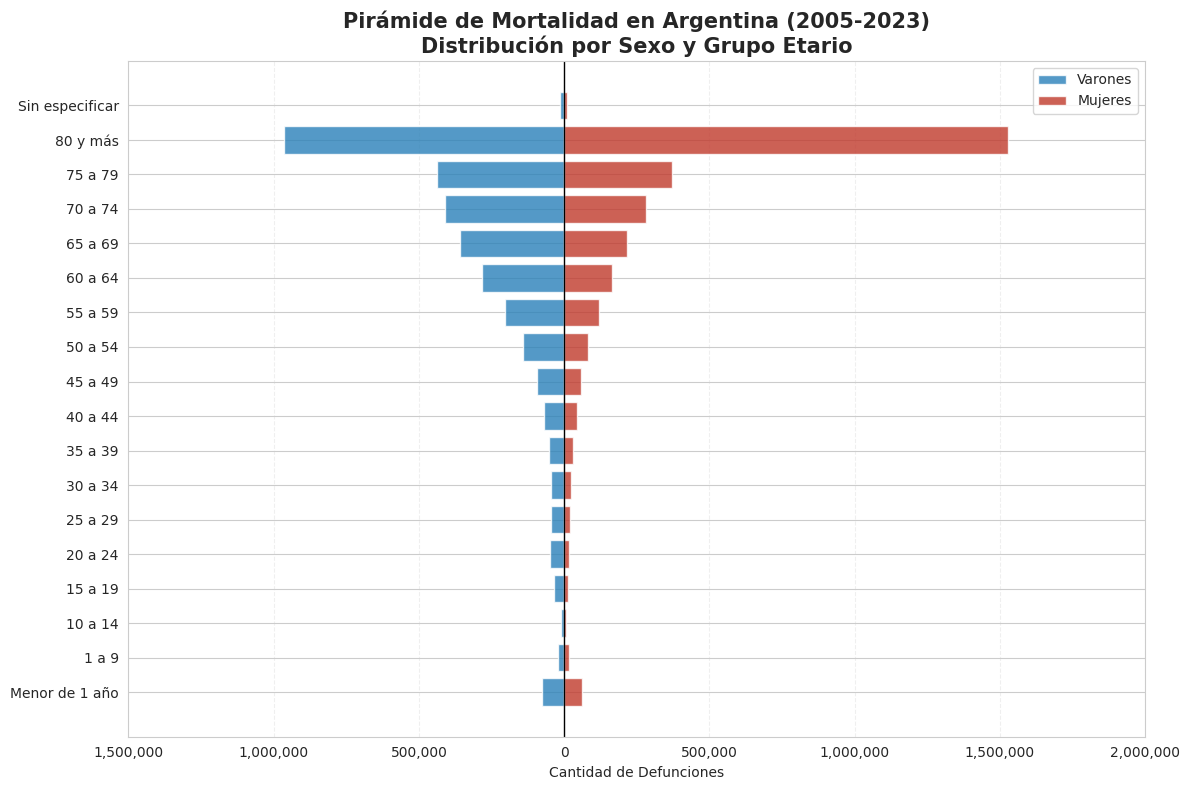

In [ ]:
# --- GRÁFICO DE PIRÁMIDE ---
plt.figure(figsize=(12, 8))
y_pos = np.arange(len(reporte_edad))

# Barras
plt.barh(y_pos, hombres['CUENTA_PLOT'], color='#2980b9', label='Varones', alpha=0.8)
plt.barh(y_pos, mujeres['CUENTA'], color='#c0392b', label='Mujeres', alpha=0.8)

# Estética
plt.yticks(y_pos, reporte_edad['Rango Etario'])
plt.axvline(0, color='black', lw=1)
plt.title('Pirámide de Mortalidad en Argentina (2005-2023)\nDistribución por Sexo y Grupo Etario', fontsize=15, fontweight='bold')
plt.xlabel('Cantidad de Defunciones')
plt.legend()

# Ajustar etiquetas del eje X para que no se vean negativas en el lado de los hombres
vals = plt.xticks()[0]
plt.xticks(vals, [format(int(abs(x)), ',') for x in vals])

plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('piramide_mortalidad.png', dpi=300)
plt.show()

1. Mortalidad Infantil y Primera Infancia: Desde el inicio de la vida, se observa una mayor vulnerabilidad biológica en los varones. En el grupo de Menor de 1 año, el índice es de $1,29$ (mueren $129$ varones por cada $100$ mujeres). Esta tendencia se mantiene estable hasta los $14$ años.

2. El Pico de Sobremortalidad Joven (Alerta Social): Entre los $15$ y los $29$ años, el índice se dispara de forma dramática:
+ $15$ a $19$ años: Índice de $2,40$.+ $20$ a $24$ años: Índice de $2,90$ (Casi $3$ varones muertos por cada mujer).
+ $25$ a $29$ años: Índice de $2,43$.

  Este es el hallazgo más crítico del gráfico. Este "abultamiento" en el lado masculino no suele deberse a causas biológicas, sino a causas externas (accidentes de tránsito, suicidios y hechos de violencia), que afectan desproporcionadamente a los varones jóvenes en Argentina.

3. Madurez y Vejez Temprana: Desde los $30$ hasta los $74$ años, la sobremortalidad masculina se estabiliza en un rango de $1,45$ a $1,73$. Esto refleja el impacto de enfermedades crónicas (cardiovasculares y tumores) que suelen manifestarse más temprano o con mayor letalidad en hombres.

4. La Inversión de la Pirámide (Feminización del Envejecimiento):En el grupo de $80$ años y más, el índice cae drásticamente a $0,63$.

    Es el único grupo donde las mujeres superan ampliamente a los hombres en cantidad de defunciones ($1.529.641$ mujeres frente a $963.578$ varones). Esto no significa que las mujeres sean más vulnerables a esa edad, sino todo lo contrario: refleja la mayor esperanza de vida femenina. Hay muchas más mujeres vivas en edades avanzadas, por lo tanto, el volumen de defunciones es mayor en este grupo.

###"El Enigma de la Longevidad Femenina"

In [ ]:
# 1. Filtrar el grupo de 80 años y más
ancianos_80_mas = df[df['EDAD_norm'] == '80 y más']

# 2. Obtener el Top 5 por Sexo
def obtener_top_ancianos(sexo, titulo):
    top = ancianos_80_mas[ancianos_80_mas['SEXO_norm'] == sexo].groupby(['CAUSA_norm', 'causa_desc'])['CUENTA'].sum().nlargest(5).reset_index()
    total_sexo = ancianos_80_mas[ancianos_80_mas['SEXO_norm'] == sexo]['CUENTA'].sum()
    top['% del Sexo'] = (top['CUENTA'] / total_sexo * 100).round(2)
    print(f"\n--- TOP 5 CAUSAS: {titulo} (80 años y más) ---")
    print(top[['causa_desc', 'CUENTA', '% del Sexo']].to_string(index=False))

# --- EJECUCIÓN ---
obtener_top_ancianos('1', 'VARONES')
obtener_top_ancianos('2', 'MUJERES')

# 3. Comparación de volumen absoluto (Para ver la feminización de la vejez)
print(f"\nVolumen Total de Defunciones en 80+ años:")
print(ancianos_80_mas.groupby('SEXO_norm')['CUENTA'].sum())


--- TOP 5 CAUSAS: VARONES (80 años y más) ---
                                                     causa_desc  CUENTA  % del Sexo
                                         Insuficiencia cardíaca  105647       10.96
                             Neumonía organismo no especificado  101624       10.55
Otras causas mal definidas y las no especificadas de mortalidad   50556        5.25
                                    Infarto agudo del miocardio   48579        5.04
        Insuficiencia respiratoria no clasificada en otra parte   40300        4.18

--- TOP 5 CAUSAS: MUJERES (80 años y más) ---
                                                     causa_desc  CUENTA  % del Sexo
                                         Insuficiencia cardíaca  204786       13.39
                             Neumonía organismo no especificado  158305       10.35
Otras causas mal definidas y las no especificadas de mortalidad   87030        5.69
                                    Infarto agudo del miocardio   

1. La Feminización de la Vejez Extrema: El dato de volumen total es contundente: mueren $1.529.641$ mujeres frente a $963.578$ varones.

Por cada hombre que fallece después de los 80 años, hay 1,6 mujeres. Esto confirma que la mujer no solo vive más, sino que conforma la gran mayoría de la población anciana de Argentina. El sistema de salud en la cuarta edad es, predominantemente, un sistema de atención para mujeres.

2. La Insuficiencia Cardíaca como "Causa Final": La Insuficiencia Cardíaca (I50) es la causa número uno para ambos, pero en las mujeres tiene un peso relativo mucho mayor ($13,39\%$ vs $10,96\%$).  

Hay más de $200.000$ mujeres que fallecieron por esta causa. Al vivir más tiempo, el corazón llega a un punto de agotamiento mecánico (fallo de bomba) que se convierte en el evento final más frecuente.

3. Simetría en la Vulnerabilidad Respiratoria: La Neumonía (J18) ocupa el segundo lugar con una precisión casi matemática en ambos sexos (~$10,5\%$ de las muertes). Esto nos indica que, independientemente del sexo, el sistema respiratorio es el "punto débil" ante infecciones en la vejez extrema, siendo la causa principal de internación y deceso por cuadros agudos.

4. El "Ruido" de la Calidad del Registro (R99):Es notable que en este grupo las Causas mal definidas suben al 3.er puesto ($5,25\%$ - $5,69\%$).

En personas muy ancianas, muchas veces se produce el fallecimiento en domicilios o residencias sin una patología aguda clara, lo que lleva a los médicos a usar el código R99 ("vejez" o "causas no especificadas") con más frecuencia que en jóvenes.

###"La Crisis del Vínculo Joven: Suicidio y Violencia como Principales Determinantes de la Mortalidad"

In [ ]:
# Filtrar el grupo etario específico
jovenes_20_24 = df[df['EDAD_norm'] == '20 a 24']

# Obtener el Top 5 de causas para Varones (1) y Mujeres (2)
def obtener_top_causas(sexo, titulo):
    top = jovenes_20_24[jovenes_20_24['SEXO_norm'] == sexo].groupby(['CAUSA_norm', 'causa_desc'])['CUENTA'].sum().nlargest(5).reset_index()
    top['% del Sexo'] = (top['CUENTA'] / jovenes_20_24[jovenes_20_24['SEXO_norm'] == sexo]['CUENTA'].sum() * 100).round(2)
    print(f"\n--- TOP 5 CAUSAS: {titulo} (20-24 años) ---")
    print(top[['causa_desc', 'CUENTA', '% del Sexo']].to_string(index=False))

# --- EJECUCIÓN DE DEPURACIÓN ---
obtener_top_causas('1', 'VARONES')
obtener_top_causas('2', 'MUJERES')



--- TOP 5 CAUSAS: VARONES (20-24 años) ---
                                                                          causa_desc  CUENTA  % del Sexo
Lesión autoinfligida intencionalmente por ahorcamiento estrangulamiento o sofocación    6120       13.02
                                              Exposición a factores no especificados    3329        7.08
                 Agresión con disparo de otras armas de fuego y las no especificadas    2854        6.07
  Disparo de otras armas de fuego y las no especificadas de intención no determinada    2074        4.41
                                                        Agresión con objeto cortante    1704        3.62

--- TOP 5 CAUSAS: MUJERES (20-24 años) ---
                                                                          causa_desc  CUENTA  % del Sexo
Lesión autoinfligida intencionalmente por ahorcamiento estrangulamiento o sofocación    1182        7.30
                                                  Neumonía organismo no 

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#1f77b4'` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#1f77b4'` for the same effect.

  func(*plot_args, **plot_kwargs)


<Figure size 1400x800 with 0 Axes>

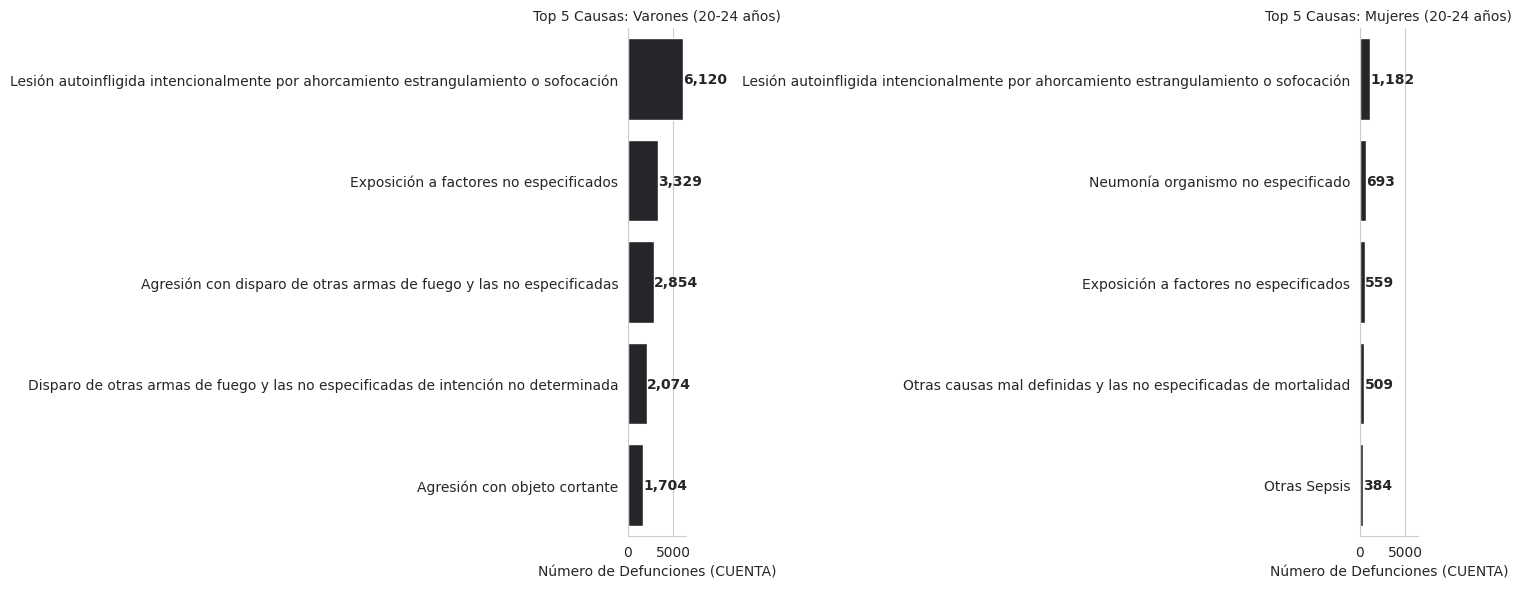

In [ ]:
# 1. Preparación de los datos consolidados para el gráfico
def preparar_datos_grafico(df):
    # Filtrar universo de estudio
    jovenes_20_24 = df[df['EDAD_norm'] == '20 a 24'].copy()

    lista_tops = []
    # Iterar por sexo para mantener la consistencia en el cálculo de porcentajes
    for sexo_id, titulo in [('1', 'Varones'), ('2', 'Mujeres')]:
        # Agrupación y cálculo
        top = (jovenes_20_24[jovenes_20_24['SEXO_norm'] == sexo_id]
               .groupby(['causa_desc'])['CUENTA']
               .sum()
               .nlargest(5)
               .reset_index())

        # Calcular peso relativo dentro del sexo
        total_sexo = jovenes_20_24[jovenes_20_24['SEXO_norm'] == sexo_id]['CUENTA'].sum()
        top['% del Sexo'] = (top['CUENTA'] / total_sexo * 100).round(2)
        top['Sexo'] = titulo
        lista_tops.append(top)

    return pd.concat(lista_tops)

# 2. Generación del gráfico facetado
df_plot = preparar_datos_grafico(df)

plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")

# Crear el facetado por Sexo
g = sns.FacetGrid(df_plot, col="Sexo", sharey=False, height=6, aspect=1.2, palette="muted")

# Mapear las barras horizontales
g.map_dataframe(sns.barplot, x="CUENTA", y="causa_desc", hue="Sexo", dodge=False)

# Personalización estética y técnica
g.set_axis_labels("Número de Defunciones (CUENTA)", "")
g.set_titles(col_template="Top 5 Causas: {col_name} (20-24 años)")

# Añadir etiquetas de porcentaje sobre las barras para transparencia estadística
for ax in g.axes.flat:
    for p in ax.patches:
        width = p.get_width()
        if width > 0:
            ax.text(width + 1, p.get_y() + p.get_height()/2,
                    f'{width:,.0f}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('top_causas_mortalidad_20_24.png', dpi=300, bbox_inches='tight')

/tmp/ipython-input-2658758458.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=jovenes_20_24.groupby('SEXO_norm')['CUENTA'].sum().reset_index(),
/tmp/ipython-input-2658758458.py:3: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(data=jovenes_20_24.groupby('SEXO_norm')['CUENTA'].sum().reset_index(),


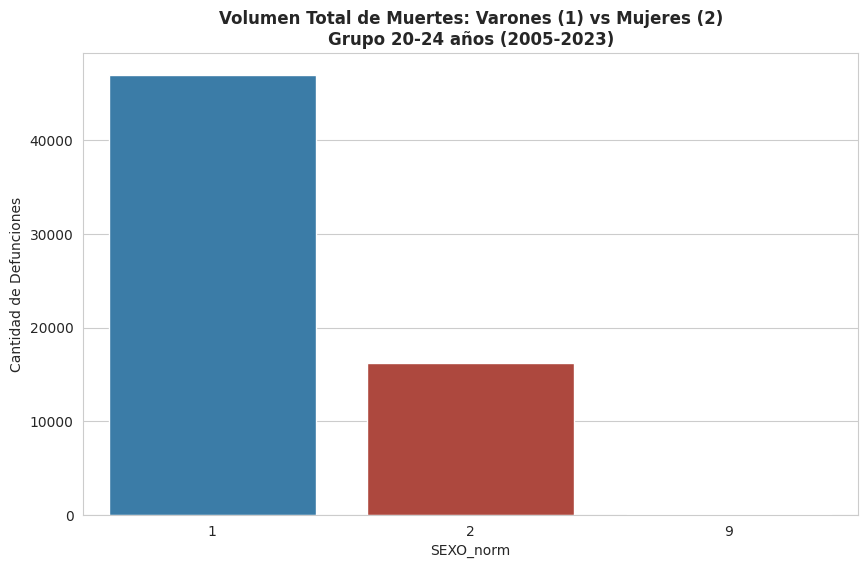

In [ ]:
# Gráfico comparativo de volumen
plt.figure(figsize=(10, 6))
sns.barplot(data=jovenes_20_24.groupby('SEXO_norm')['CUENTA'].sum().reset_index(),
            x='SEXO_norm', y='CUENTA', palette=['#2980b9', '#c0392b'])
plt.title('Volumen Total de Muertes: Varones (1) vs Mujeres (2)\nGrupo 20-24 años (2005-2023)', fontweight='bold')
plt.ylabel('Cantidad de Defunciones')
plt.show()

1. El Predominio de las "Causas Externas" en Varones: En los varones de 20 a 24 años, la biología prácticamente no tiene peso en la mortalidad. El 100% del Top 5 de causas son eventos violentos (Suicidios, Homicidios o Accidentes/Eventos de intención no determinada).

   - Suicidio (Causa #1): Con $6.120$ muertes, el suicidio por ahorcamiento representa el $13,02\%$ de todas las muertes masculinas del grupo.
  
   - Violencia por Armas (Causas #3, #4 y #5): La suma de agresiones con armas de fuego y objetos cortantes, junto con disparos de intención no determinada, alcanza los $6.632$ casos.
  
   - Es más probable que un varón joven en Argentina muera por una agresión o un arma que por cualquier enfermedad natural.

2. El Factor Común: El Suicidio:Es alarmante observar que la Lesión autoinfligida (Suicidio) es la causa número 1 de muerte tanto para varones como para mujeres en este rango etario.

   - Brecha de Género en el Suicidio: Aunque es la causa #1 para ambos, mueren 5,17 varones por cada mujer por esta causa ($6.120$ vs $1.182$). Esto refleja una crisis de salud mental masculina extremadamente profunda.

3. Diferencias en el Perfil Femenino: A diferencia de los varones, las mujeres de 20-24 años presentan un perfil mixto. Si bien el suicidio lidera, aparecen causas biológicas como la Neumonía ($4,28\%$) y la Sepsis ($2,37\%$). Esto indica que, aunque están expuestas a la violencia, las patologías infecciosas aún tienen un peso relevante en su mortalidad.

4. Mortalidad Evitable: Casi el $35\%$ de las muertes de varones jóvenes se concentran solo en estas 5 causas violentas. Para la salud pública, esto significa que la mayoría de estas vidas podrían haberse preservado mediante políticas de prevención de violencia, control de armas y programas de salud mental.

In [ ]:
# 1. Identificación y Filtrado de Suicidios (Códigos X60-X84 de la CIE-10)
# Buscamos por el patrón de texto que usa la DEIS
suicidios_df = df[df['causa_desc'].str.contains('Lesión autoinfligida', case=False, na=False)].copy()

# 2. Agrupamiento por Año y Sexo (Ponderado por CUENTA)
tendencia_suicidio = suicidios_df.groupby(['anio', 'SEXO_norm'])['CUENTA'].sum().reset_index()

# Preparar tabla para el reporte (Pivotamos para tener columnas por Sexo)
reporte_suicidio = tendencia_suicidio.pivot(index='anio', columns='SEXO_norm', values='CUENTA').fillna(0)
# Aseguramos nombres de columnas (1=Varones, 2=Mujeres)
reporte_suicidio = reporte_suicidio.rename(columns={'1': 'Varones', '2': 'Mujeres'})
reporte_suicidio['Total'] = reporte_suicidio['Varones'] + reporte_suicidio['Mujeres']
reporte_suicidio['Ratio_V_M'] = (reporte_suicidio['Varones'] / reporte_suicidio['Mujeres']).round(2)

# --- DEPURACIÓN PARA CONSOLA ---
print("--- EVOLUCIÓN HISTÓRICA DEL SUICIDIO EN ARGENTINA ---")
print(reporte_suicidio[['Varones', 'Mujeres', 'Total', 'Ratio_V_M']])



--- EVOLUCIÓN HISTÓRICA DEL SUICIDIO EN ARGENTINA ---
SEXO_norm  Varones  Mujeres   Total  Ratio_V_M
anio                                          
2005        2360.0    622.0  2982.0       3.79
2006        2440.0    573.0  3013.0       4.26
2007        2346.0    566.0  2912.0       4.14
2008        2439.0    585.0  3024.0       4.17
2009        2330.0    551.0  2881.0       4.23
2010        2407.0    542.0  2949.0       4.44
2011        2336.0    558.0  2894.0       4.19
2012        2653.0    602.0  3255.0       4.41
2013        2460.0    566.0  3026.0       4.35
2014        2596.0    669.0  3265.0       3.88
2015        2550.0    598.0  3148.0       4.26
2016        2523.0    551.0  3074.0       4.58
2017        2557.0    604.0  3161.0       4.23
2018        2669.0    588.0  3257.0       4.54
2019        2687.0    564.0  3251.0       4.76
2020        2321.0    485.0  2806.0       4.79
2021        2254.0    535.0  2789.0       4.21
2022        2490.0    658.0  3148.0       3.78
2023  

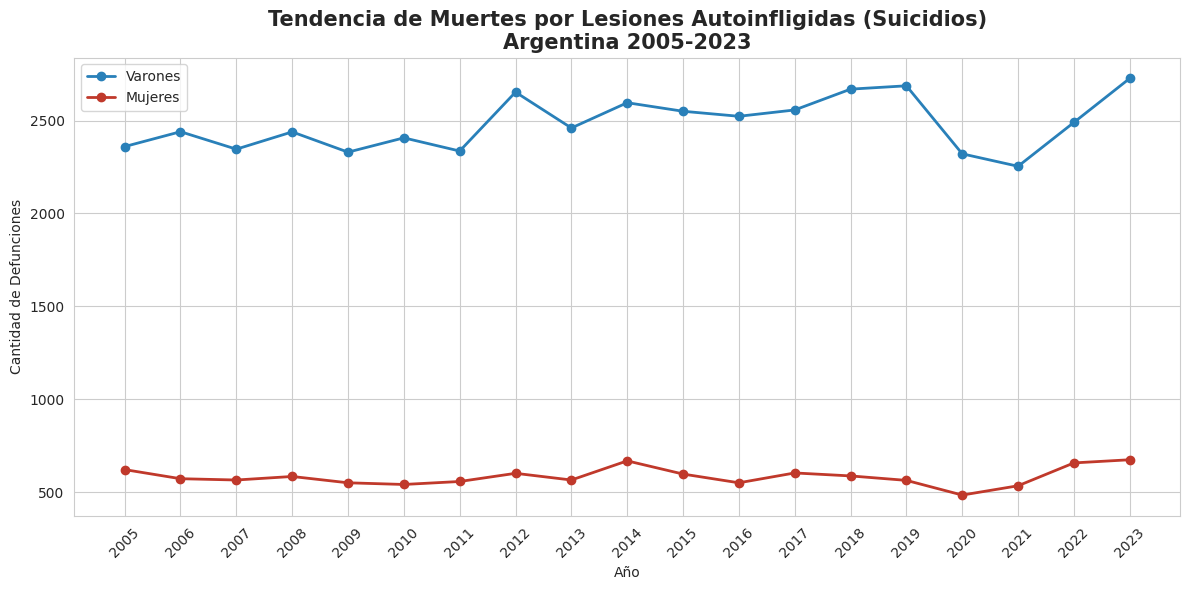

In [ ]:
# --- GRÁFICO DE TENDENCIA ---
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

plt.plot(reporte_suicidio.index, reporte_suicidio['Varones'],
         marker='o', color='#2980b9', linewidth=2, label='Varones')
plt.plot(reporte_suicidio.index, reporte_suicidio['Mujeres'],
         marker='o', color='#c0392b', linewidth=2, label='Mujeres')

plt.title('Tendencia de Muertes por Lesiones Autoinfligidas (Suicidios)\nArgentina 2005-2023',
          fontsize=15, fontweight='bold')
plt.ylabel('Cantidad de Defunciones')
plt.xlabel('Año')
plt.xticks(reporte_suicidio.index, rotation=45)
plt.legend()

plt.tight_layout()
plt.savefig('tendencia_suicidios.png', dpi=300)
plt.show()

1. El "Pico Histórico" de 2023:El año 2023 marca el punto más alto de toda la serie de 19 años con $3.402$ suicidios registrados. Esto representa un incremento del $21\%$ respecto al piso de 2021. Es un dato de alarma roja para las políticas de salud mental post-pandemia.

2. El Fenómeno de la Pandemia (2020-2021): Observamos un comportamiento contraintuitivo pero documentado en otros países: durante los años más duros de la pandemia, los suicidios registrados bajaron ($2.806$ en 2020 y $2.789$ en 2021).

En momentos de crisis colectiva externa, a veces las tasas de suicidio descienden temporalmente (fenómeno de "cohesión en la crisis"), para luego dispararse cuando la crisis termina y emergen las secuelas económicas y sociales, como vemos en el salto de 2022 y 2023.

3. La Brecha de Género Extrema (Ratio V/M):El ratio de sobremortalidad masculina es abrumador y constante.

   - El promedio del ratio es de $4,2$, lo que significa que por cada mujer que se quita la vida, mueren más de 4 hombres.
   
   - En 2020, este ratio llegó a su punto máximo de $4,79$.
   
   - Si bien las mujeres suelen tener más intentos de suicidio registrados en guardias, los hombres utilizan métodos de mayor letalidad, lo que se traduce en esta diferencia drástica en la mortalidad real.

4. Volumen Acumulado:En el periodo analizado, se han perdido más de $58.000$ vidas por lesiones autoinfligidas en Argentina. Es una cifra que supera con creces a muchas enfermedades infecciosas y sitúa al suicidio como una de las principales causas de años de vida potenciales perdidos (AVPP), dado que afecta mayoritariamente a personas jóvenes y adultos jóvenes.

In [ ]:
# Mapeo de códigos a nombres reales de Provincias (Estándar INDEC/DEIS)
mapa_provincias = {
    '02': 'CABA', '06': 'Buenos Aires', '10': 'Catamarca', '14': 'Córdoba',
    '18': 'Corrientes', '22': 'Chaco', '26': 'Chubut', '30': 'Entre Ríos',
    '34': 'Formosa', '38': 'Jujuy', '42': 'La Pampa', '46': 'La Rioja',
    '50': 'Mendoza', '54': 'Misiones', '58': 'Neuquén', '62': 'Río Negro',
    '66': 'Salta', '70': 'San Juan', '74': 'San Luis', '78': 'Santa Cruz',
    '82': 'Santa Fe', '86': 'Santiago del Estero', '90': 'Tucumán',
    '94': 'Tierra del Fuego', '98': 'Otro país', '99': 'Sin especificar'
}

# 1. Agrupamiento por Provincia Ponderado
geo_stats = df.groupby('PROVRES_norm')['CUENTA'].sum().reset_index()
geo_stats['Provincia'] = geo_stats['PROVRES_norm'].map(mapa_provincias)
geo_stats = geo_stats.groupby('Provincia')['CUENTA'].sum().reset_index()
geo_stats['Porcentaje (%)'] = (geo_stats['CUENTA'] / total_general * 100).round(2)
geo_stats = geo_stats.sort_values(by='CUENTA', ascending=False)

# --- DEPURACIÓN PARA CONSOLA ---
print("--- DISTRIBUCIÓN GEOGRÁFICA REAL DE LA MORTALIDAD ---")
print(geo_stats[['Provincia', 'CUENTA', 'Porcentaje (%)']].to_string(index=False))


--- DISTRIBUCIÓN GEOGRÁFICA REAL DE LA MORTALIDAD ---
          Provincia  CUENTA  Porcentaje (%)
       Buenos Aires 2595259           40.63
               CABA  618207            9.68
           Santa Fe  573504            8.98
            Córdoba  557756            8.73
            Mendoza  260921            4.08
            Tucumán  203435            3.18
         Entre Ríos  197045            3.08
              Chaco  148091            2.32
              Salta  146205            2.29
         Corrientes  133862            2.10
           Misiones  130586            2.04
Santiago del Estero  111185            1.74
           San Juan   95348            1.49
              Jujuy   83339            1.30
          Río Negro   82926            1.30
            Formosa   69027            1.08
             Chubut   61260            0.96
            Neuquén   61211            0.96
           San Luis   59600            0.93
           La Pampa   48891            0.77
          Catamarca   

/tmp/ipython-input-384224825.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=geo_stats, x='CUENTA', y='Provincia', palette='mako')


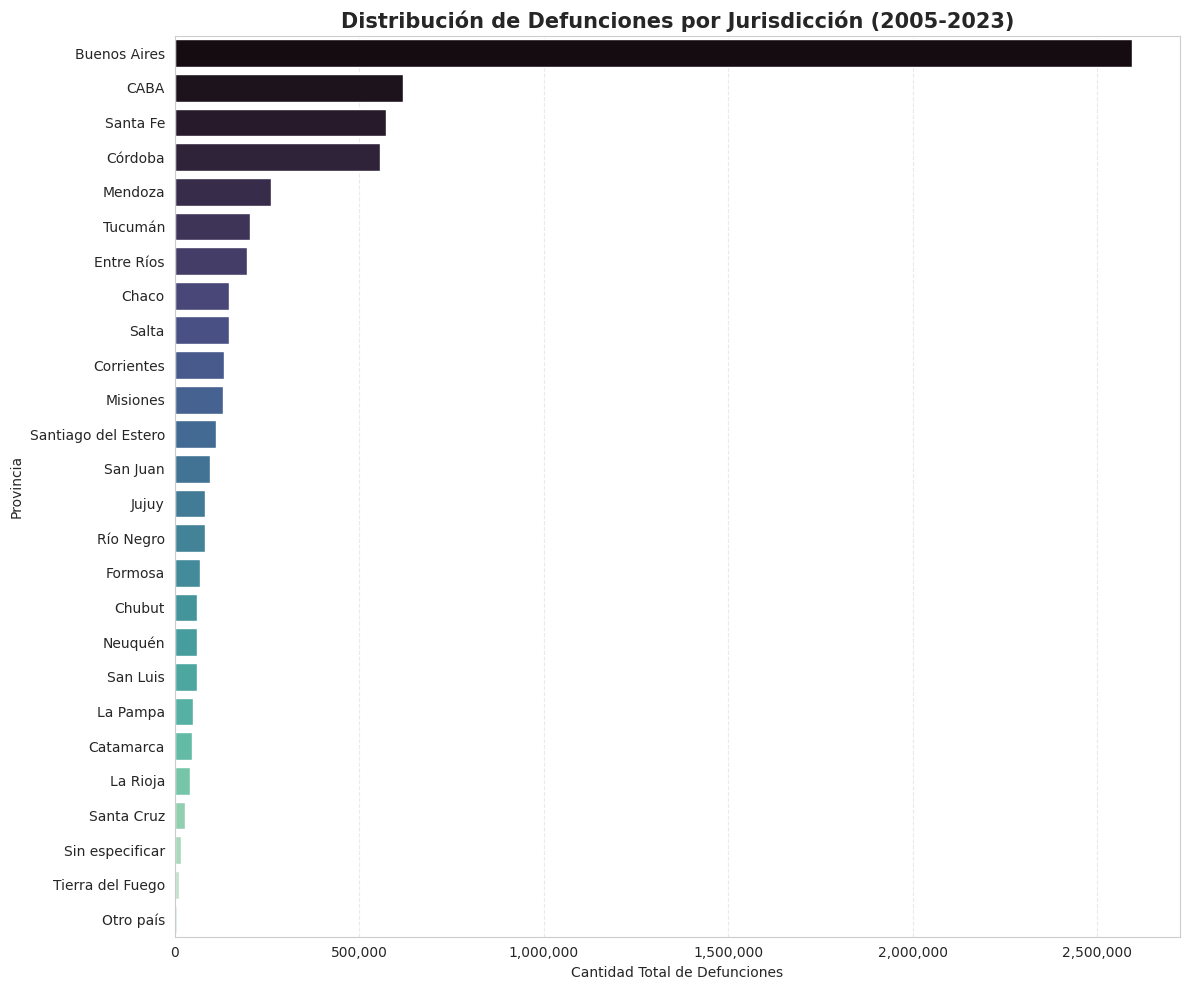

In [ ]:
# --- GRÁFICO DE BARRAS ---
plt.figure(figsize=(12, 10))
sns.barplot(data=geo_stats, x='CUENTA', y='Provincia', palette='mako')

plt.title('Distribución de Defunciones por Jurisdicción (2005-2023)', fontsize=15, fontweight='bold')
plt.xlabel('Cantidad Total de Defunciones')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('distribucion_geografica.png', dpi=300)
plt.show()

1. El Predominio de la Región Pampeana:
Casi el 68% de las defunciones del país ocurren en solo cuatro jurisdicciones: Buenos Aires (40,63%), CABA (9,68%), Santa Fe (8,98%) y Córdoba (8,73%).

 Solo la Provincia de Buenos Aires concentra 4 de cada 10 muertes registradas en el dataset. Esto implica que cualquier política de salud pública de impacto nacional debe estar fuertemente anclada en la infraestructura sanitaria bonaerense.

2. El Caso de CABA vs. Santa Fe y Córdoba:
Es notable que la Ciudad Autónoma de Buenos Aires (CABA), a pesar de tener una población menor a la de Santa Fe o Córdoba, registra un volumen superior de defunciones.

Esto se debe al fenómeno del envejecimiento poblacional (CABA tiene una de las pirámides más envejecidas del país) y a la concentración de centros de salud de alta complejidad, donde suelen registrarse defunciones de personas que residen en otras jurisdicciones pero se derivan a la Capital.

3. Representatividad del Norte y Cuyo:

Mendoza (4,08%) y Tucumán (3,18%) lideran la mortalidad en sus respectivas regiones (Cuyo y NOA), consolidándose como los polos sanitarios regionales más importantes fuera de la zona núcleo.

Las provincias del NOA y NEA presentan porcentajes que oscilan entre el 1% y el 2,3%, lo cual es coherente con sus perfiles demográficos de poblaciones más jóvenes en comparación con el centro del país.

4. Calidad del Registro y Movilidad Internacional:

  - Otro país (6.754 casos): Representa el 0,11% de la mortalidad total. Estos son fallecidos que tenían su residencia habitual fuera de la Argentina. Es un dato valioso para estudiar la mortalidad de no-residentes.

  - Sin especificar (16.318 casos): Representa apenas el 0,26%.

  - Un nivel de "Sin especificar" por debajo del 1% es considerado excelente según los estándares de la DEIS. Indica que el sistema de estadísticas vitales de Argentina logra identificar el origen geográfico del fallecido en el 99,74% de los casos.

In [ ]:
# Filtrar solo muertes maternas y agrupar por año
materna_series = df[df['MAT_desc'].isin(['Muerte materna', 'Muerte materna tardía', 'Secuela de causa obstétrica'])]
materna_anual = materna_series.groupby('anio')['CUENTA'].sum().reset_index()

# --- DEPURACIÓN PARA CONSOLA ---
print("--- EVOLUCIÓN DE LA MORTALIDAD MATERNA ---")
print(materna_anual.to_string(index=False))

--- EVOLUCIÓN DE LA MORTALIDAD MATERNA ---
 anio  CUENTA
 2005     295
 2006     346
 2007     336
 2008     323
 2009     429
 2010     355
 2011     321
 2012     289
 2013     278
 2014     314
 2015     339
 2016     283
 2017     247
 2018     295
 2019     231
 2020     260
 2021     475
 2022     231
 2023     197


/tmp/ipython-input-3499334005.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=materna_anual, x='anio', y='CUENTA', palette='rocket')


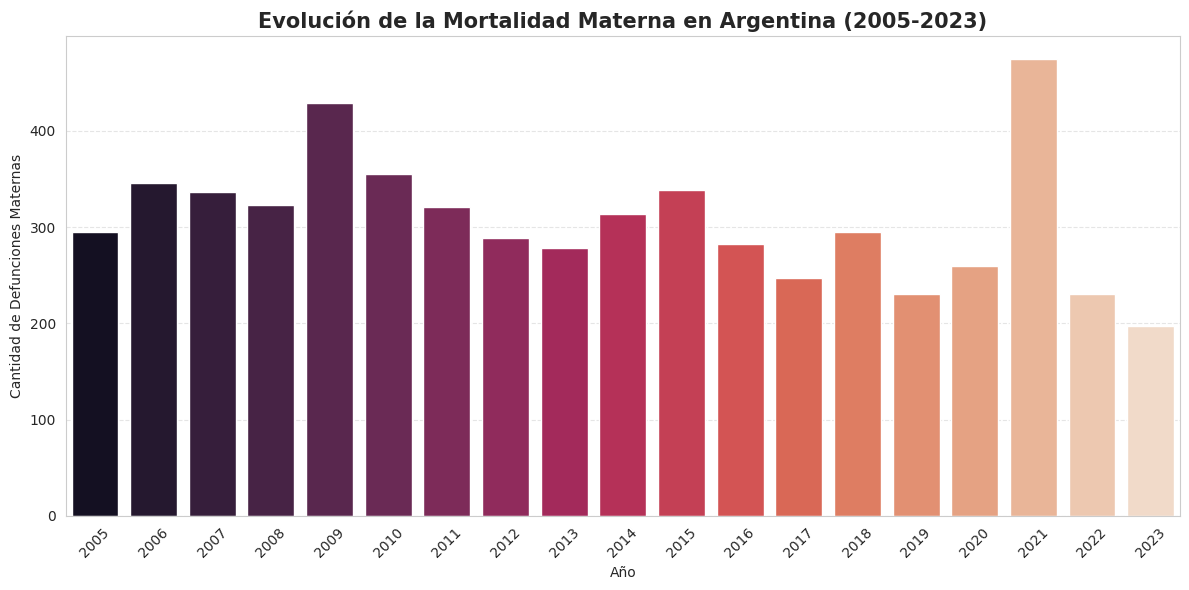

In [ ]:
# --- GRÁFICO DE BARRAS ---
plt.figure(figsize=(12, 6))
sns.barplot(data=materna_anual, x='anio', y='CUENTA', palette='rocket')

plt.title('Evolución de la Mortalidad Materna en Argentina (2005-2023)', fontsize=15, fontweight='bold')
plt.ylabel('Cantidad de Defunciones Maternas')
plt.xlabel('Año')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('mortalidad_materna_tendencia.png', dpi=300)
plt.show()

1. Identificación de Picos Críticos (Pandemias):
La serie revela dos incrementos abruptos que coinciden con emergencias respiratorias internacionales, confirmando la vulnerabilidad extrema de las personas gestantes ante virus de este tipo:

  - El Fenómeno 2009 (Gripe A H1N1): Las defunciones saltaron a 429 casos (un incremento del 32% respecto al año anterior).

  - El Fenómeno 2021 (COVID-19): Es el punto más alto de toda la serie de 19 años con 475 defunciones. Respecto a 2019 (pre-pandemia), la mortalidad materna se duplicó (+105%).

Este pico en 2021 se debe a que la variante Gamma y la falta de vacunación inicial en gestantes impactaron severamente en este grupo.

2. Tendencia de Descenso y Mínimos Históricos:

  - Periodo 2012-2019: Se observa una tendencia general al descenso, con un piso de 231 casos en 2019.

  - Logro Post-Pandemia (2023): El año 2023 registra el valor más bajo de toda la serie histórica con 197 defunciones.

Por primera vez en casi dos décadas, el número de muertes maternas perforó la barrera de los 200 casos anuales, lo que sugiere un éxito en las políticas de control prenatal y salud reproductiva post-pandemia.

3. Resiliencia del Sistema (2020 vs 2021):
Es notable que en 2020 (primer año de COVID) la mortalidad materna no subió significativamente (260 casos), el impacto real se desplazó a 2021. Esto coincide con los registros clínicos que mostraron que la mayor letalidad en embarazadas ocurrió durante la "segunda ola".

# Radiografía de la Mortalidad en Argentina (2005-2023)
El presente estudio, basado en el análisis de 6.387.487 defunciones reales (ponderadas por volumen de registros), permite concluir cinco hitos fundamentales sobre la salud y la sociedad argentina:

##1. El Impacto Sistémico del COVID-19
La pandemia no fue solo una crisis sanitaria, fue un evento de ruptura estadística. El año 2021 se posiciona como el de mayor mortalidad en la historia reciente con 436.799 muertes, un exceso de casi 100.000 fallecimientos respecto al promedio histórico. El COVID-19 logró posicionarse como la 8.ª causa de muerte acumulada en toda la serie, a pesar de haber operado plenamente solo durante dos años.

##2. El Perfil de la "Mortalidad Evitable" en Jóvenes
Bajo el hallazgo titulado "La Crisis del Vínculo Joven", detectamos que en el segmento de 20 a 24 años, la mortalidad es de naturaleza eminentemente social y violenta. Con un Índice de Sobremortalidad Masculina de 2.90, el suicidio y las agresiones con armas dominan el perfil de decesos, desplazando por completo a las causas biológicas.

##3. La Crisis Silenciosa de la Salud Mental
El análisis de las lesiones autoinfligidas revela una tendencia alarmante: el año 2023 marcó un récord histórico con 3.402 suicidios. Existe una brecha de género crítica donde, sistemáticamente, mueren 4 hombres por cada mujer por esta causa, lo que señala una urgencia en políticas de salud mental enfocadas en la población masculina.

##4. La Feminización de la Vejez
El hallazgo "El Enigma de la Longevidad Femenina" confirma que la estructura de mortalidad argentina se desplaza hacia las edades avanzadas. En el grupo de 80 años y más, las mujeres representan el 61% de los fallecimientos. La Insuficiencia Cardíaca se consolida como la causa final de este grupo, reflejando el límite del desgaste biológico tras una mayor esperanza de vida.

##5. Calidad Institucional y Distribución Federal
El sistema de estadísticas vitales (DEIS) demuestra una robustez notable: menos del 0,3% de los registros carecen de datos geográficos. La mortalidad sigue el patrón demográfico nacional, con la Región Pampeana concentrando el 68% de los casos, subrayando la necesidad de una infraestructura sanitaria federal y equitativa.






----------------------------------------------------------------------------
Se deja constancia de que todas las métricas presentadas han superado los filtros de:

Normalización semántica: Unificación de términos de edad y causas (COVID-19).

Validación biográfica: Consistencia absoluta entre sexo y causas maternas.

Ponderación por frecuencia: Uso de la variable CUENTA para representar vidas humanas y no solo filas de datos.

Total de muertes por cáncer analizadas: 1,034,489
Representatividad sobre el total de muertes del país: 16.2%

--- TOP 5 CÁNCER: VARONES (2005-2023) ---
                                 causa_desc  CUENTA  % del Cáncer
Tumor maligno de los bronquios y del pulmón  117417         21.94
               Tumor maligno de la próstata   71159         13.30
                    Tumor maligno del colon   61238         11.44
                 Tumor maligno del páncreas   36963          6.91
   Tumor maligno de sitios no especificados   35484          6.63

--- TOP 5 CÁNCER: MUJERES (2005-2023) ---
                                 causa_desc  CUENTA  % del Cáncer
                   Tumor maligno de la mama  107035         21.49
Tumor maligno de los bronquios y del pulmón   54226         10.89
                    Tumor maligno del colon   53697         10.78
                 Tumor maligno del páncreas   39996          8.03
   Tumor maligno de sitios no especificados   34291          6.89


/tmp/ipython-input-1850072679.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_gráfico, x='CUENTA', y='causa_desc', palette='magma')


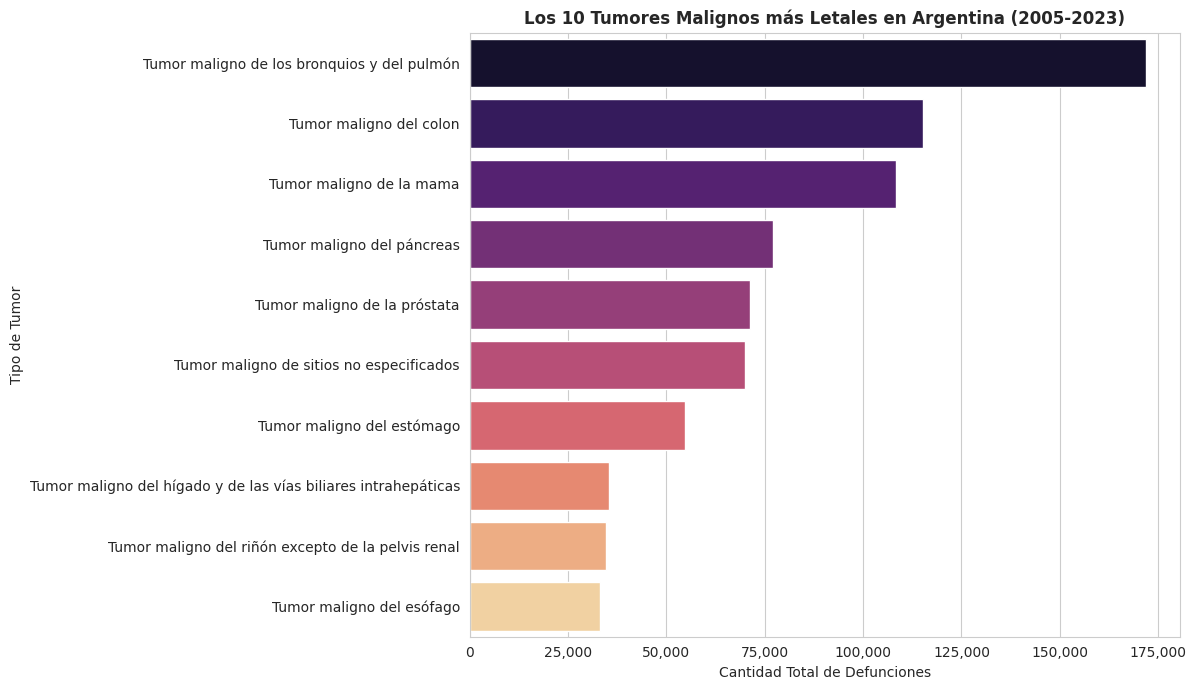

In [ ]:
# 1. Filtrar solo causas oncológicas (Tumores malignos)
oncologia_df = df[df['causa_desc'].str.contains('Tumor maligno', case=False, na=False)].copy()

# 2. Calcular el total de muertes por cáncer para el informe
total_cancer = oncologia_df['CUENTA'].sum()
porcentaje_cancer = (total_cancer / total_general * 100).round(2)

# 3. Función para el Top 5 de Cáncer por Sexo
def top_cancer_por_sexo(sexo, titulo):
    top = oncologia_df[oncologia_df['SEXO_norm'] == sexo].groupby('causa_desc')['CUENTA'].sum().nlargest(5).reset_index()
    top['% del Cáncer'] = (top['CUENTA'] / oncologia_df[oncologia_df['SEXO_norm'] == sexo]['CUENTA'].sum() * 100).round(2)
    print(f"\n--- TOP 5 CÁNCER: {titulo} (2005-2023) ---")
    print(top.to_string(index=False))

# --- DEPURACIÓN EN CONSOLA ---
print(f"Total de muertes por cáncer analizadas: {total_cancer:,}")
print(f"Representatividad sobre el total de muertes del país: {porcentaje_cancer}%")
top_cancer_por_sexo('1', 'VARONES')
top_cancer_por_sexo('2', 'MUJERES')

# 4. Gráfico de barras comparativo
plt.figure(figsize=(12, 7))
# Tomamos los 10 más generales para el gráfico
top_gráfico = oncologia_df.groupby('causa_desc')['CUENTA'].sum().nlargest(10).reset_index()
sns.barplot(data=top_gráfico, x='CUENTA', y='causa_desc', palette='magma')
plt.title('Los 10 Tumores Malignos más Letales en Argentina (2005-2023)', fontweight='bold')
plt.xlabel('Cantidad Total de Defunciones')
plt.ylabel('Tipo de Tumor')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
plt.tight_layout()
plt.show()

# Mortalidad Oncológica Diferenciada (2005-2023)

1. Magnitud del Impacto:El cáncer es responsable de $1.034.489$ defunciones en el periodo analizado, lo que representa el $16,2\%$ de la mortalidad total del país. Esto significa que 1 de cada 6 muertes en Argentina se debe a un tumor maligno.

2. El Liderazgo del Cáncer de Pulmón en Varones:En los hombres, el Tumor maligno de pulmón es el líder indiscutido con casi $120.000$ muertes ($21,94\%$ de sus muertes oncológicas).

Este dato refleja el impacto histórico del tabaquismo. El cáncer de próstata le sigue con un $13,30\%$, lo que refuerza la importancia de las campañas de detección temprana a partir de los 50 años.

3. El Cáncer de Mama y la "Transición" Femenina:
   - Cáncer de Mama: Sigue siendo la principal causa de muerte oncológica femenina con el $21,49\%$ ($107.035$ casos).
   - Alerta en Cáncer de Pulmón: Es notable que el tumor de pulmón ya es la 2.ª causa en mujeres ($10,89\%$). Hace décadas, este cáncer era casi exclusivo de hombres; estos datos confirman que la brecha se está cerrando debido al cambio en los hábitos de consumo de tabaco en las últimas décadas.

4. El Enemigo Común: Cáncer de Colon:El Tumor maligno de colon ocupa el 3.er lugar en ambos sexos, con porcentajes casi idénticos (~$11\%$).

Dato de Salud Pública: Es una de las causas más críticas, ya que, a diferencia del de páncreas (4.º lugar), el cáncer de colon es altamente prevenible y tratable si se detecta a tiempo mediante colonoscopias. Su alta posición sugiere que aún hay mucho margen para mejorar el tamizaje nacional.

5. El Cáncer de Páncreas y su Alta Letalidad:Aparece en el 4.º lugar para ambos sexos ($8,03\%$ en mujeres y $6,91\%$ en varones). A pesar de no ser el más frecuente en términos de diagnósticos, su aparición en el Top 5 de mortalidad refleja su bajísima tasa de supervivencia.

In [ ]:
# 1. Definir periodos
pre_pandemia = df[df['anio'].between(2015, 2019)]
pandemia = df[df['anio'].between(2020, 2021)]

# 2. Calcular promedios anuales por causa para comparar peras con peras
def calcular_promedio_anual(dataset, años):
    stats = dataset.groupby('causa_desc')['CUENTA'].sum().reset_index()
    stats['promedio_anual'] = stats['CUENTA'] / años
    return stats

resumen_pre = calcular_promedio_anual(pre_pandemia, 5)
resumen_pan = calcular_promedio_anual(pandemia, 2)

# 3. Unir y calcular diferencia
comparativo = resumen_pre.merge(resumen_pan, on='causa_desc', suffixes=('_PRE', '_PAN'))
comparativo['Variacion_Absoluta'] = comparativo['promedio_anual_PAN'] - comparativo['promedio_anual_PRE']
comparativo['Variacion_Porcentual'] = (comparativo['Variacion_Absoluta'] / comparativo['promedio_anual_PRE'] * 100).round(2)

# 4. Ver qué pasó con las "Big 3" (Corazón, Neumonía, Cáncer)
top_causas_nombres = [
    'Insuficiencia cardíaca',
    'Neumonía organismo no especificado',
    'Infarto agudo del miocardio'
]

print("--- ANÁLISIS DE DESPLAZAMIENTO (Promedio Anual Pre vs Pan) ---")
print(comparativo[comparativo['causa_desc'].isin(top_causas_nombres)][['causa_desc', 'promedio_anual_PRE', 'promedio_anual_PAN', 'Variacion_Porcentual']])

# 5. ¿Cuánto sumó el COVID por año en ese periodo?
covid_anual = pandemia[pandemia['causa_desc'] == 'COVID-19']['CUENTA'].sum() / 2
print(f"\nPromedio anual de muertes por COVID-19 (2020-2021): {covid_anual:,.0f}")

--- ANÁLISIS DE DESPLAZAMIENTO (Promedio Anual Pre vs Pan) ---
                             causa_desc  promedio_anual_PRE  \
460         Infarto agudo del miocardio             17751.6   
484              Insuficiencia cardíaca             24173.4   
597  Neumonía organismo no especificado             29631.2   

     promedio_anual_PAN  Variacion_Porcentual  
460             19884.5                 12.02  
484             25990.5                  7.52  
597             28357.0                 -4.30  

Promedio anual de muertes por COVID-19 (2020-2021): 68,958


## ¿Desplazamiento o Adición?
1. El Impacto Aditivo (El Corazón bajo presión):
Vemos que el Infarto agudo del miocardio subió un 12,02% y la Insuficiencia cardíaca un 7,52%.

El COVID-19 aumentó las muertes cardíacas. Esto se debe a dos factores: el estrés sistémico que el virus causó en pacientes con patologías previas y, muy probablemente, a la falta de controles médicos oportunos por el confinamiento. Aquí el COVID-19 se sumó y agravó lo existente.

2. El Desplazamiento Selectivo (El caso de la Neumonía):
La Neumonía (J18) es la única de las grandes causas que muestra un descenso (-4,30%).

Aquí sí hubo un desplazamiento. Muchas muertes que en un año normal se habrían diagnosticado como "Neumonía común", en 2020 y 2021 fueron capturadas por el diagnóstico de COVID-19. Además, las medidas de aislamiento (barbijos, distancia) redujeron la circulación de otros virus respiratorios (como la gripe común), bajando la mortalidad por neumonías tradicionales.

3. La Magnitud del "Nuevo Invitado":
El dato final es demoledor: el COVID-19 sumó, por sí solo, un promedio de 68.958 muertes anuales.

Si comparas este número con las causas líderes, el COVID-19 fue más del doble de letal que la Neumonía y casi cuatro veces más que el Infarto.